# Retrieve chembl data

The purpose of this notebook is to retrieve all compounds on Chembl with measured microsomal stability readouts (intrinsic clearance).

In [87]:
from pathlib import Path
import pathlib
import csv

import numpy as np
import pandas as pd
import seaborn as sns
from tqdm.notebook import tqdm

Protein and data variables.

In [ ]:
readout = 'microsomal_clint'

In [5]:
# define paths
HERE = Path(pathlib.Path.cwd())
DATA = HERE / f"data_{readout}"
DATA.mkdir(parents=True, exist_ok=True)

### Download ligands and bioactivity data from Chembl.

In [6]:
from chembl_webresource_client.new_client import new_client
from tqdm.notebook import tqdm
import concurrent.futures

/home/corey/miniconda3/envs/docking_md/lib/python3.11/site-packages/chembl_webresource_client/__init__.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __version__ = __import__('pkg_resources').get_distribution('chembl_webresource_client').version


In [ ]:
########## 1. Query all activities ##########

clint_readouts = ['CL'] # readouts can vary by Chembl version so these may not work for future versions.
all_activities = []

print("Fetching activities...")

for clint_readout in clint_readouts:
    activities = tqdm(new_client.activity.filter(
        standard_type=clint_readout,
        # target_organism__in=['Homo sapiens'],
        relation='='
    ).only(
        "activity_id",
        "assay_chembl_id",
        "molecule_chembl_id",
        "standard_type",
        "standard_units",
        "relation",
        "standard_value",
        "target_chembl_id",
    ))
    all_activities.extend(activities)

print(f"Total activities fetched: {len(all_activities)}")


Fetching activities...


  0%|          | 0/62441 [00:00<?, ?it/s]

Total activities fetched: 62441


In [44]:
########## 2. Helper to use the fetched Chembl records to query for all relevant data associated with them ##########

def process_activity(act):
    record = {
        "activity_id": act.get("activity_id"),
        "assay_chembl_id": act.get("assay_chembl_id"),
        "molecule_chembl_id": act.get("molecule_chembl_id"),
        "type": act.get("standard_type"),
        "standard_units": act.get("standard_units"),
        "relation": act.get("relation"),
        "standard_value": act.get("standard_value"),
        "target_chembl_id": act.get("target_chembl_id"),
        "target_organism": None,
        "assay_description": None,
        "assay_type": None,
        "smiles": None
    }

    try:
        assay = new_client.assay.get(act["assay_chembl_id"])
        record["assay_description"] = assay.get("description")
        record["assay_type"] = assay.get("assay_type")

        molecule = new_client.molecule.get(act["molecule_chembl_id"])
        if molecule and molecule.get("molecule_structures"):
            record["smiles"] = molecule["molecule_structures"].get("canonical_smiles")

        if act.get("target_chembl_id"):
            target = new_client.target.get(act["target_chembl_id"])
            record["target_organism"] = target.get("organism")

    except Exception as e:
        record["error"] = str(e)

    return record


In [45]:
########## 3. Code to run the query in parallel ##########

results = []
max_workers = 20

print("Processing records...")

def init_worker_cache():
    import requests_cache
    requests_cache.install_cache('chembl_cache', backend='sqlite', expire_after=7*24*60*60)

with concurrent.futures.ProcessPoolExecutor(max_workers=max_workers, initializer=init_worker_cache) as executor:
    results = list(tqdm(executor.map(process_activity, all_activities), total=len(all_activities)))


print("Done!")


Processing records...


  0%|          | 0/62441 [00:00<?, ?it/s]

Done!


In [46]:
len(results)

62441

In [47]:
# Because we queried more than one LogD readout, we need to de-duplicate.

unique_activities = list({a["activity_id"]: a for a in results}.values())

In [48]:
# Check distribution of logd's

df = pd.DataFrame(unique_activities)
df['standard_value'] = df['standard_value'].astype(float)

/tmp/ipykernel_36301/1747405060.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')  # Rotate x labels
/tmp/ipykernel_36301/1747405060.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')  # Rotate x labels


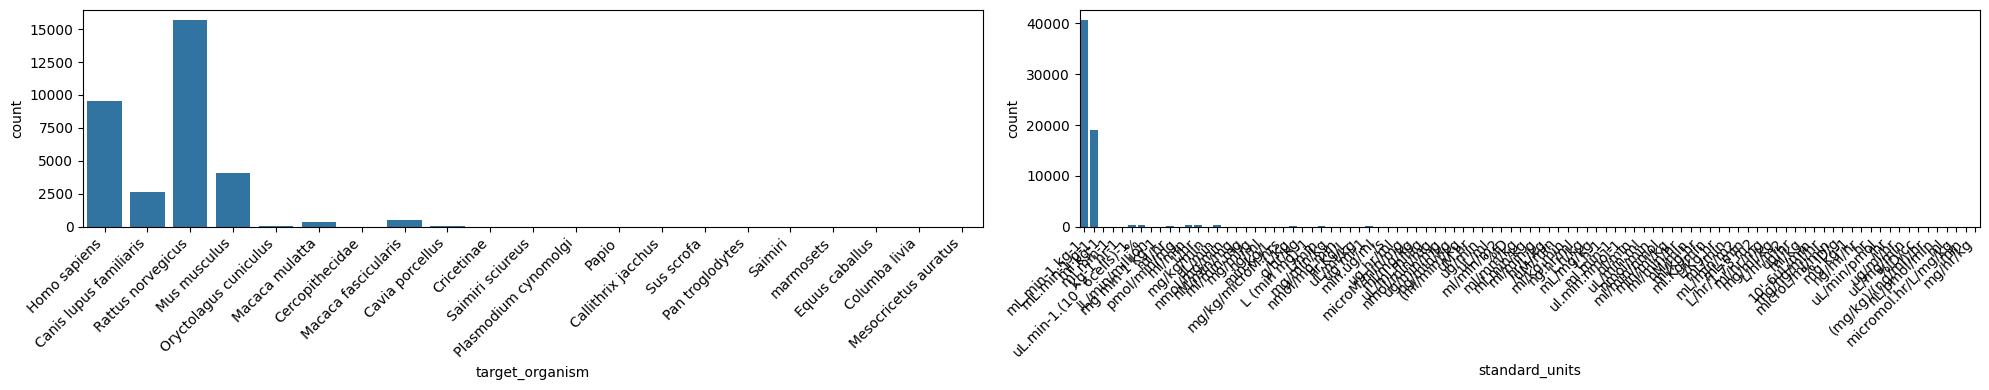

In [71]:
import matplotlib.pyplot as plt
import seaborn as sns

cols = ["target_organism", "standard_units"]
f, axs = plt.subplots(1, len(cols), figsize=(20, 4))

for ax, col in zip(axs, cols):
    sns.countplot(data=df, x=col, ax=ax)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')  # Rotate x labels

f.tight_layout()

Only keep human records.

In [86]:
filtered_df = df[df['target_organism'] == 'Homo sapiens']
len(filtered_df)

9580

Do we still get a huge mix of units?

/tmp/ipykernel_36301/2408245298.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')  # Rotate x labels
/tmp/ipykernel_36301/2408245298.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')  # Rotate x labels


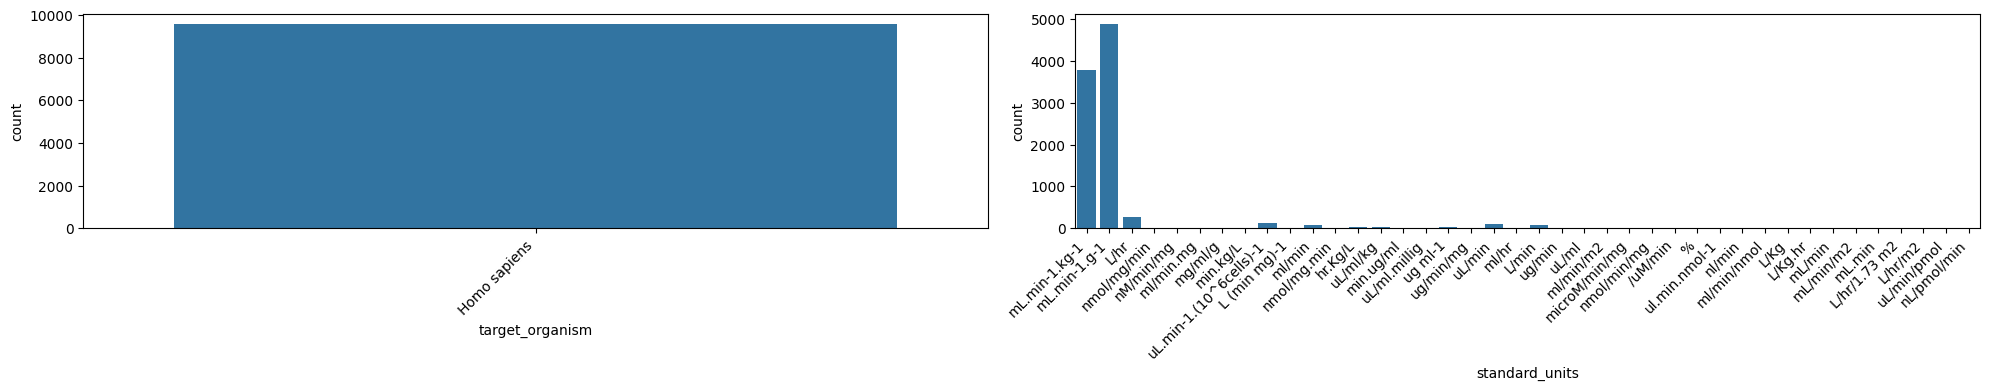

In [78]:
import matplotlib.pyplot as plt
import seaborn as sns

cols = ["target_organism", "standard_units"]
f, axs = plt.subplots(1, len(cols), figsize=(20, 4))

for ax, col in zip(axs, cols):
    sns.countplot(data=filtered_df, x=col, ax=ax)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')  # Rotate x labels

f.tight_layout()

Let's keep and train on vivo clint (ml/min/kg). We'll need to convert those with units of ml/min/g by dividing by 1000.  

In [94]:
clint_df = filtered_df[(filtered_df['standard_units'] == 'mL.min-1.g-1') | (filtered_df['standard_units'] == 'mL.min-1.kg-1')]

In [95]:
clint_df = clint_df.assign(
    clint = np.where(clint_df['standard_units'] == 'mL.min-1.g-1', clint_df['standard_value'] / 1000, clint_df['standard_value']),
    units = 'mL.min-1.kg-1'
)

clint_df.head()

,activity_id,assay_chembl_id,molecule_chembl_id,type,standard_units,relation,standard_value,target_chembl_id,target_organism,assay_description,assay_type,smiles,clint,units
0,33031,CHEMBL695026,CHEMBL306457,CL,mL.min-1.kg-1,=,47.7,CHEMBL372,Homo sapiens,In vitro oxidative metabolic stability measure...,F,NC(=O)C(C[C@H](O)[C@H](Cc1ccccc1)NC(=O)c1cnc2c...,47.7,mL.min-1.kg-1
1,34270,CHEMBL695026,CHEMBL66457,CL,mL.min-1.kg-1,=,4.9,CHEMBL372,Homo sapiens,In vitro oxidative metabolic stability measure...,F,CC(C)(O)CC[C@H](C[C@H](O)[C@H](Cc1ccccc1)NC(=O...,4.9,mL.min-1.kg-1
2,34274,CHEMBL695026,CHEMBL304053,CL,mL.min-1.kg-1,=,16.5,CHEMBL372,Homo sapiens,In vitro oxidative metabolic stability measure...,F,CC(C)(O)CCC(C[C@H](O)[C@H](Cc1ccccc1F)NC(=O)c1...,16.5,mL.min-1.kg-1
3,35507,CHEMBL695026,CHEMBL68366,CL,mL.min-1.kg-1,=,8.0,CHEMBL372,Homo sapiens,In vitro oxidative metabolic stability measure...,F,CC(C)(F)CC[C@H](C[C@H](O)[C@H](Cc1ccccc1)NC(=O...,8.0,mL.min-1.kg-1
13,39099,CHEMBL695026,CHEMBL303673,CL,mL.min-1.kg-1,=,6.1,CHEMBL372,Homo sapiens,In vitro oxidative metabolic stability measure...,F,O=C(N[C@@H](Cc1ccccc1)[C@@H](O)CC(C(=O)NO)C1CC...,6.1,mL.min-1.kg-1


We will consider Clint > 500 to be unreliable and omit them.

In [103]:
clint_df = clint_df[clint_df['clint'] < 500]
len(clint_df)

8592

<Axes: xlabel='clint', ylabel='Count'>

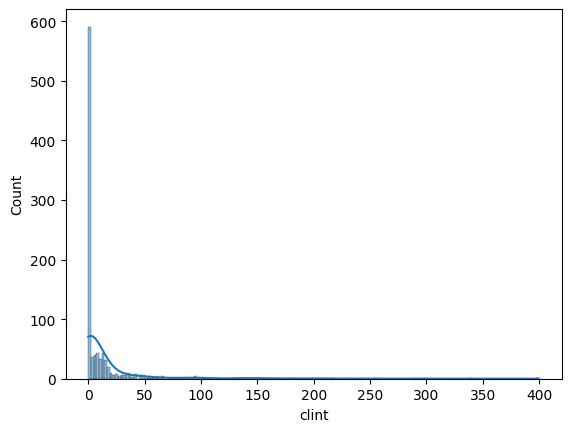

In [104]:
sns.histplot(data=clint_df.head(1000), x="clint", kde=True)

In [106]:
# Dump to file both the curated Clints and all species, in case we're interested in them later.

clint_df.to_csv(DATA / f"{readout}_chembl.csv")
df.to_csv(DATA / f"{readout}_all_species_chembl.csv")